# LTGuardian AML™ - Synthetic Data Generation

This notebook generates synthetic AML (Anti-Money Laundering) transaction data modelled after
the AMLSim / Swedish Swish methodology described in the referenced thesis.

## Objectives
1. Create realistic **normal player** behaviour (3 types)
2. Simulate **session-based suspicious players** (6 risk patterns)
3. Generate **explicit transfer transaction edges** (`from_account → to_account`) supporting all 7 laundering topologies
4. Produce structured **node file** and **edge file** for graph-based AML modelling

## Laundering Topologies Simulated
Fan-out · Fan-in · Scatter-Gather · Gather-Scatter · Cycle · Bipartite · Stack

## Output Files
| File | Description |
|---|---|
| `aml_synthetic_data.csv` | Full TxLog with all records |
| `aml_nodes.csv` | Per-account node features (Table II) incl. `money_launderer` label |
| `aml_edges.csv` | Directed edge list: `from_account`, `to_account`, `amount`, `timestamp`, `currency`, `channel`, `topology_type` |

## Dataset Schema (TxLog)
- **Graph fields**: `from_account`, `to_account`, `transaction_id`, `timestamp`, `amount`, `currency`, `channel`, `action_type`
- **Topology fields**: `topology_type`, `money_launderer`
- **Game context**: `player_id`, `session_id`, `bet_amount`, `balance_before/after`, `deposit_amount`, `withdraw_amount`
- **Behavioural**: `device`, `ip_address`, `location`, `time_since_last_action`, `bet_direction`, `game_result`


In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import random

In [2]:
def random_ip():
    return f"10.{random.randint(0,255)}.{random.randint(0,255)}.{random.randint(0,255)}"

def random_device():
    return random.choice(["iPhone", "Android", "PC", "ETG"])

def random_location():
    return random.choice(["Macau", "US", "EU", "VPN"])

def random_game_result():
    return random.choice(["Win", "Lose"])

# ── IBM-compatible currency list (16 currencies matching IBM AML dataset) ──
CURRENCIES = [
    "US Dollar", "Euro", "UK Pound", "Swiss Franc",
    "Canadian Dollar", "Australian Dollar", "Yuan", "Yen",
    "Indian Rupee", "Ruble", "Mexican Peso", "Brazilian Real",
    "Saudi Riyal", "Shekel", "Bitcoin", "Swedish Krona",
]

# FX rates relative to USD (approximate mid-market rates)
FX_RATES = {
    "US Dollar": 1.0,        "Euro": 0.92,          "UK Pound": 0.79,
    "Swiss Franc": 0.90,     "Canadian Dollar": 1.35,"Australian Dollar": 1.53,
    "Yuan": 7.24,            "Yen": 149.5,           "Indian Rupee": 83.1,
    "Ruble": 90.0,           "Mexican Peso": 17.1,   "Brazilian Real": 4.97,
    "Saudi Riyal": 3.75,     "Shekel": 3.68,         "Bitcoin": 0.000015,
    "Swedish Krona": 10.4,
}

# IBM-compatible payment formats
PAYMENT_FORMATS = ["ACH", "Wire", "Credit Card", "Cash", "Cheque", "Reinvestment", "Swish"]

# Bank ID pool — simulates a multi-institution transaction network
BANK_IDS = [f"BANK_{i:03X}" for i in range(1, 25)]


def random_currency():
    """Return one of the IBM-compatible currency names."""
    return random.choice(CURRENCIES)

def random_payment_format():
    """Return a random IBM-style payment format."""
    return random.choice(PAYMENT_FORMATS)

def random_channel():
    """Legacy alias — delegates to random_payment_format."""
    return random_payment_format()

def random_bank():
    """Return a random bank institution ID."""
    return random.choice(BANK_IDS)

def fx_convert(amount: float, from_currency: str, to_currency: str) -> float:
    """
    Convert amount from from_currency to to_currency using USD as the pivot.
    Returns the received amount rounded to 2 decimal places.
    """
    usd = amount / FX_RATES.get(from_currency, 1.0)
    return round(usd * FX_RATES.get(to_currency, 1.0), 2)

def jitter_seconds(base, jitter=3):
    return base + random.uniform(-jitter, jitter)


## Helper Functions
Utility functions for generating random contextual data (IP addresses, devices, locations, game results)

In [3]:
def generate_action(
    player_id,
    session_id,
    timestamp,
    balance,
    bet_amount,
    interval_sec,
    bet_direction="player"
):
    balance_after      = balance - bet_amount
    paying_currency    = random_currency()
    receiving_currency = random_currency()
    amount_received    = fx_convert(bet_amount, paying_currency, receiving_currency)
    from_bank          = random_bank()
    return {
        # ── graph / IBM routing fields ────────────────────────────────
        "player_id":          player_id,
        "from_account":       player_id,
        "to_account":         "PLATFORM",
        "from_bank":          from_bank,
        "to_bank":            "PLATFORM_BANK",
        # ── IBM-compatible amount / currency fields ───────────────────
        "timestamp":          timestamp,
        "amount_paid":        bet_amount,
        "paying_currency":    paying_currency,
        "amount_received":    amount_received,
        "receiving_currency": receiving_currency,
        "payment_format":     "Credit Card",
        # ── legacy / game context fields ──────────────────────────────
        "session_id":               session_id,
        "amount":                   bet_amount,
        "currency":                 paying_currency,
        "channel":                  "Platform",
        "action_type":              "bet",
        "bet_amount":               bet_amount,
        "balance_before":           balance,
        "balance_after":            balance_after,
        "deposit_amount":           None,
        "withdraw_amount":          None,
        "game_result":              random_game_result(),
        "device":                   random_device(),
        "ip_address":               random_ip(),
        "location":                 random_location(),
        "time_since_last_action":   interval_sec,
        "bet_direction":            bet_direction,
        "topology_type":            None,
        "money_launderer":          False,
    }, balance_after


## Action Generators
Functions to generate different types of player actions (bets, deposits, withdrawals)

In [4]:
def generate_deposit(player_id, session_id, timestamp, balance, deposit_amount,
                     channel=None, currency=None):
    """Generate a deposit action (SOURCE -> player_id)."""
    balance_after      = balance + deposit_amount
    paying_currency    = currency or random_currency()
    receiving_currency = random_currency()
    amount_received    = fx_convert(deposit_amount, paying_currency, receiving_currency)
    fmt                = channel or random.choice(["ACH", "Wire", "Credit Card", "Cash", "Cheque"])
    to_bank            = random_bank()
    return {
        # ── graph / IBM routing fields ────────────────────────────────
        "player_id":          player_id,
        "from_account":       "SOURCE",
        "to_account":         player_id,
        "from_bank":          "EXTERNAL",
        "to_bank":            to_bank,
        # ── IBM-compatible amount / currency fields ───────────────────
        "timestamp":          timestamp,
        "amount_paid":        deposit_amount,
        "paying_currency":    paying_currency,
        "amount_received":    amount_received,
        "receiving_currency": receiving_currency,
        "payment_format":     fmt,
        # ── legacy / game context fields ──────────────────────────────
        "session_id":               session_id,
        "amount":                   deposit_amount,
        "currency":                 paying_currency,
        "channel":                  fmt,
        "action_type":              "deposit",
        "bet_amount":               None,
        "balance_before":           balance,
        "balance_after":            balance_after,
        "deposit_amount":           deposit_amount,
        "withdraw_amount":          None,
        "game_result":              None,
        "device":                   random_device(),
        "ip_address":               random_ip(),
        "location":                 random_location(),
        "time_since_last_action":   None,
        "bet_direction":            None,
        "topology_type":            None,
        "money_launderer":          False,
    }, balance_after


def generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount,
                        channel=None, currency=None):
    """Generate a withdrawal action (player_id -> SINK)."""
    balance_after      = balance - withdraw_amount
    paying_currency    = currency or random_currency()
    receiving_currency = random_currency()
    amount_received    = fx_convert(withdraw_amount, paying_currency, receiving_currency)
    fmt                = channel or random.choice(["ACH", "Wire", "Credit Card", "Cash", "Cheque"])
    from_bank          = random_bank()
    return {
        # ── graph / IBM routing fields ────────────────────────────────
        "player_id":          player_id,
        "from_account":       player_id,
        "to_account":         "SINK",
        "from_bank":          from_bank,
        "to_bank":            "EXTERNAL",
        # ── IBM-compatible amount / currency fields ───────────────────
        "timestamp":          timestamp,
        "amount_paid":        withdraw_amount,
        "paying_currency":    paying_currency,
        "amount_received":    amount_received,
        "receiving_currency": receiving_currency,
        "payment_format":     fmt,
        # ── legacy / game context fields ──────────────────────────────
        "session_id":               session_id,
        "amount":                   withdraw_amount,
        "currency":                 paying_currency,
        "channel":                  fmt,
        "action_type":              "withdrawal",
        "bet_amount":               None,
        "balance_before":           balance,
        "balance_after":            balance_after,
        "deposit_amount":           None,
        "withdraw_amount":          withdraw_amount,
        "game_result":              None,
        "device":                   random_device(),
        "ip_address":               random_ip(),
        "location":                 random_location(),
        "time_since_last_action":   None,
        "bet_direction":            None,
        "topology_type":            None,
        "money_launderer":          False,
    }, balance_after


def generate_transfer(from_account, to_account, timestamp, amount,
                      currency=None, channel=None,
                      topology_type=None, money_launderer=True):
    """
    Explicit account-to-account transfer edge used by topology subgraphs.
    Deliberately uses exotic currencies and Wire/ACH/Cash formats to simulate
    cross-border layering behaviour as seen in real laundering networks.
    """
    paying_currency    = currency or random_currency()
    receiving_currency = random_currency()
    amount_received    = fx_convert(amount, paying_currency, receiving_currency)
    fmt                = channel or random.choice(["Wire", "ACH", "Cash", "Reinvestment"])
    from_bank          = random_bank()
    to_bank            = random_bank()
    return {
        # ── graph / IBM routing fields ────────────────────────────────
        "player_id":          from_account,
        "from_account":       from_account,
        "to_account":         to_account,
        "from_bank":          from_bank,
        "to_bank":            to_bank,
        # ── IBM-compatible amount / currency fields ───────────────────
        "timestamp":          timestamp,
        "amount_paid":        amount,
        "paying_currency":    paying_currency,
        "amount_received":    amount_received,
        "receiving_currency": receiving_currency,
        "payment_format":     fmt,
        # ── legacy / topology context fields ──────────────────────────
        "session_id":               None,
        "amount":                   amount,
        "currency":                 paying_currency,
        "channel":                  fmt,
        "action_type":              "transfer",
        "bet_amount":               None,
        "balance_before":           None,
        "balance_after":            None,
        "deposit_amount":           None,
        "withdraw_amount":          None,
        "game_result":              None,
        "device":                   None,
        "ip_address":               random_ip(),
        "location":                 random_location(),
        "time_since_last_action":   None,
        "bet_direction":            None,
        "topology_type":            topology_type,
        "money_launderer":          money_launderer,
    }


## Normal Player Simulators

Generate realistic baseline behavior for 3 types of normal players:
- **Type A**: Casual Low Bettor (small bets, slow rhythm, stable)
- **Type B**: Medium Stable Bettor (consistent range, long sessions)
- **Type C**: Hot/Cold Player (variance based on wins/losses, chase behavior)

In [5]:
def simulate_normal_player_A(player_id, num_sessions=5, start_date=None):
    """
    Normal Type A - Casual Low Bettor
    - Small bets (10-50)
    - Slow rhythm (5-12 seconds between bets)
    - No sudden spikes
    - Linear deposit/withdraw patterns
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    
    actions = []
    
    for sess_idx in range(num_sessions):
        session_id = f"{player_id}_S{sess_idx:03d}"
        session_start = start_date + timedelta(days=random.randint(0, 30), hours=random.randint(8, 22))
        
        # Initial deposit
        initial_deposit = random.randint(200, 500)
        balance = 0
        action, balance = generate_deposit(player_id, session_id, session_start, balance, initial_deposit)
        actions.append(action)
        
        # Play session: 15-30 bets
        timestamp = session_start + timedelta(seconds=random.randint(10, 60))
        num_bets = random.randint(15, 30)
        
        for bet_idx in range(num_bets):
            if balance < 10:
                break
                
            bet_amount = random.randint(10, 50)
            bet_amount = min(bet_amount, balance)  # Can't bet more than balance
            interval = jitter_seconds(random.uniform(5, 12))
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            
            # Update balance based on game result
            if action["game_result"] == "Win":
                win_amount = bet_amount * random.uniform(0.9, 1.0)  # ~95% payout
                balance += win_amount
                action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Withdraw remaining balance (if any)
        if balance > 50:
            timestamp += timedelta(seconds=random.randint(30, 120))
            withdraw_amount = balance * random.uniform(0.8, 1.0)  # Withdraw most of it
            action, balance = generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount)
            actions.append(action)
    
    return actions

In [6]:
def simulate_normal_player_B(player_id, num_sessions=5, start_date=None):
    """
    Normal Type B - Medium Stable Bettor
    - Bets around consistent range (50-200)
    - Mild variance
    - Long stable sessions (20-40 mins, 40-80 bets)
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    
    actions = []
    base_bet = random.randint(75, 150)  # Player's preferred bet size
    
    for sess_idx in range(num_sessions):
        session_id = f"{player_id}_S{sess_idx:03d}"
        session_start = start_date + timedelta(days=random.randint(0, 30), hours=random.randint(8, 22))
        
        # Initial deposit
        initial_deposit = random.randint(2000, 5000)
        balance = 0
        action, balance = generate_deposit(player_id, session_id, session_start, balance, initial_deposit)
        actions.append(action)
        
        # Play session: 40-80 bets
        timestamp = session_start + timedelta(seconds=random.randint(10, 60))
        num_bets = random.randint(40, 80)
        
        for bet_idx in range(num_bets):
            if balance < 50:
                break
                
            # Bet around base_bet with mild variance
            bet_amount = int(np.random.normal(base_bet, base_bet * 0.15))
            bet_amount = np.clip(bet_amount, 50, 200)
            bet_amount = min(bet_amount, balance)
            
            interval = jitter_seconds(random.uniform(4, 8))
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            
            # Update balance based on game result
            if action["game_result"] == "Win":
                win_amount = bet_amount * random.uniform(0.9, 1.0)
                balance += win_amount
                action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Withdraw remaining balance
        if balance > 100:
            timestamp += timedelta(seconds=random.randint(30, 180))
            withdraw_amount = balance * random.uniform(0.85, 1.0)
            action, balance = generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount)
            actions.append(action)
    
    return actions

In [7]:
def simulate_normal_player_C(player_id, num_sessions=5, start_date=None):
    """
    Normal Type C - Hot/Cold Player
    - Behavioral swings based on results
    - Slightly higher variance
    - Occasional chase behavior (increases bet after losses)
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    
    actions = []
    
    for sess_idx in range(num_sessions):
        session_id = f"{player_id}_S{sess_idx:03d}"
        session_start = start_date + timedelta(days=random.randint(0, 30), hours=random.randint(8, 22))
        
        # Initial deposit
        initial_deposit = random.randint(1000, 3000)
        balance = 0
        action, balance = generate_deposit(player_id, session_id, session_start, balance, initial_deposit)
        actions.append(action)
        
        # Play session with hot/cold behavior
        timestamp = session_start + timedelta(seconds=random.randint(10, 60))
        num_bets = random.randint(30, 60)
        
        current_bet = random.randint(50, 150)
        consecutive_losses = 0
        
        for bet_idx in range(num_bets):
            if balance < 20:
                break
            
            bet_amount = min(current_bet, balance)
            interval = jitter_seconds(random.uniform(3, 10))
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            
            # Update balance and adjust betting based on result
            if action["game_result"] == "Win":
                win_amount = bet_amount * random.uniform(0.9, 1.0)
                balance += win_amount
                action["balance_after"] = balance
                consecutive_losses = 0
                # Slightly increase bet on win
                current_bet = int(current_bet * random.uniform(1.0, 1.2))
            else:
                consecutive_losses += 1
                # Chase losses: increase bet after 2-3 consecutive losses
                if consecutive_losses >= 2:
                    current_bet = int(current_bet * random.uniform(1.2, 1.5))
                else:
                    current_bet = int(current_bet * random.uniform(0.9, 1.1))
            
            # Keep bet in reasonable range
            current_bet = np.clip(current_bet, 20, 300)
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Withdraw remaining balance
        if balance > 100:
            timestamp += timedelta(seconds=random.randint(30, 180))
            withdraw_amount = balance * random.uniform(0.7, 1.0)
            action, balance = generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount)
            actions.append(action)
    
    return actions

## Suspicious Player Simulators (AML Risk Patterns)

Generate 6 types of suspicious behavior patterns:
1. **Structuring**: Many small deposits to avoid attention
2. **Rapid In/Out**: Quick deposit → minimal play → immediate withdrawal
3. **High Volatility Spike**: Sudden abnormal bet size changes
4. **Multiple Accounts/Device Switching**: Coordinated behavior across accounts
5. **Bot-Like Behavior**: Perfectly consistent timing and patterns
6. **Crypto Abuse Pattern**: Intentional losses for laundering

In [8]:
def simulate_suspicious_structuring(player_id, num_sessions=3, start_date=None):
    """
    Suspicious Type 1 - Structuring Behavior
    AML RED FLAG: Many small deposits to avoid reporting thresholds
    - 15-25 small deposits (700-950 each)
    - Very low gameplay activity
    - Quick withdrawal afterward
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    
    actions = []
    
    for sess_idx in range(num_sessions):
        session_id = f"{player_id}_S{sess_idx:03d}"
        session_start = start_date + timedelta(days=random.randint(0, 10), hours=random.randint(8, 22))
        
        balance = 0
        timestamp = session_start
        
        # Multiple small deposits in quick succession
        num_deposits = random.randint(15, 25)
        for dep_idx in range(num_deposits):
            deposit_amount = random.randint(700, 950)  # Just under typical threshold
            action, balance = generate_deposit(player_id, session_id, timestamp, balance, deposit_amount)
            actions.append(action)
            timestamp += timedelta(seconds=random.randint(30, 180))  # 0.5-3 mins between deposits
        
        # Minimal gameplay (5-10 small bets only)
        timestamp += timedelta(seconds=random.randint(60, 300))
        num_bets = random.randint(5, 10)
        
        for bet_idx in range(num_bets):
            bet_amount = random.randint(10, 30)
            bet_amount = min(bet_amount, balance)
            interval = jitter_seconds(random.uniform(5, 15))
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            
            if action["game_result"] == "Win":
                win_amount = bet_amount * random.uniform(0.9, 1.0)
                balance += win_amount
                action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Quick withdrawal of nearly all funds
        timestamp += timedelta(seconds=random.randint(60, 300))
        withdraw_amount = balance * random.uniform(0.95, 0.99)
        action, balance = generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount)
        actions.append(action)
    
    return actions

In [9]:
def simulate_suspicious_rapid_inout(player_id, num_sessions=4, start_date=None):
    """
    Suspicious Type 2 - Rapid In/Out Behavior
    AML RED FLAG: Money laundering through minimal activity
    - Deposits large amount (8000-12000)
    - Bets 5-10 very small bets
    - Withdraws 95-98% immediately
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    
    actions = []
    
    for sess_idx in range(num_sessions):
        session_id = f"{player_id}_S{sess_idx:03d}"
        session_start = start_date + timedelta(days=random.randint(0, 15), hours=random.randint(8, 22))
        
        # Large deposit
        initial_deposit = random.randint(8000, 12000)
        balance = 0
        action, balance = generate_deposit(player_id, session_id, session_start, balance, initial_deposit)
        actions.append(action)
        
        # Very minimal gameplay (5-10 bets, very small amounts)
        timestamp = session_start + timedelta(seconds=random.randint(120, 300))
        num_bets = random.randint(5, 10)
        
        for bet_idx in range(num_bets):
            bet_amount = random.randint(10, 50)
            bet_amount = min(bet_amount, balance)
            interval = jitter_seconds(random.uniform(8, 20))
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            
            if action["game_result"] == "Win":
                win_amount = bet_amount * random.uniform(0.9, 1.0)
                balance += win_amount
                action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Immediate large withdrawal (95-98% of deposit)
        timestamp += timedelta(seconds=random.randint(30, 120))
        withdraw_amount = balance * random.uniform(0.95, 0.98)
        action, balance = generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount)
        actions.append(action)
    
    return actions

In [10]:
def simulate_suspicious_volatility_spike(player_id, num_sessions=3, start_date=None):
    """
    Suspicious Type 3 - High Volatility Spike
    AML RED FLAG: Abnormal behavior change
    - Normally bets 30-70
    - Suddenly bets 3000-6000 (2-3 times)
    - Returns to normal betting
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    
    actions = []
    
    for sess_idx in range(num_sessions):
        session_id = f"{player_id}_S{sess_idx:03d}"
        session_start = start_date + timedelta(days=random.randint(0, 20), hours=random.randint(8, 22))
        
        # Large deposit to enable spike behavior
        initial_deposit = random.randint(8000, 15000)
        balance = 0
        action, balance = generate_deposit(player_id, session_id, session_start, balance, initial_deposit)
        actions.append(action)
        
        timestamp = session_start + timedelta(seconds=random.randint(30, 120))
        
        # Phase 1: Normal betting (15-25 bets)
        num_normal_bets = random.randint(15, 25)
        for bet_idx in range(num_normal_bets):
            bet_amount = random.randint(30, 70)
            bet_amount = min(bet_amount, balance)
            interval = jitter_seconds(random.uniform(5, 10))
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            
            if action["game_result"] == "Win":
                win_amount = bet_amount * random.uniform(0.9, 1.0)
                balance += win_amount
                action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Phase 2: SPIKE - 2-3 massive bets
        num_spike_bets = random.randint(2, 3)
        for spike_idx in range(num_spike_bets):
            if balance < 1000:
                break
                
            spike_bet = random.randint(3000, 6000)
            spike_bet = min(spike_bet, balance)
            interval = jitter_seconds(random.uniform(10, 25))
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, spike_bet, interval
            )
            
            if action["game_result"] == "Win":
                win_amount = spike_bet * random.uniform(0.9, 1.0)
                balance += win_amount
                action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Phase 3: Return to normal betting (10-15 bets)
        num_normal_after = random.randint(10, 15)
        for bet_idx in range(num_normal_after):
            if balance < 30:
                break
                
            bet_amount = random.randint(30, 70)
            bet_amount = min(bet_amount, balance)
            interval = jitter_seconds(random.uniform(5, 10))
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            
            if action["game_result"] == "Win":
                win_amount = bet_amount * random.uniform(0.9, 1.0)
                balance += win_amount
                action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Withdraw
        if balance > 100:
            timestamp += timedelta(seconds=random.randint(30, 180))
            withdraw_amount = balance * random.uniform(0.85, 0.98)
            action, balance = generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount)
            actions.append(action)
    
    return actions

In [11]:
def simulate_suspicious_coordinated_accounts(player_ids, start_date=None):
    """
    Suspicious Type 4 - Multiple Accounts / Device Switching
    AML RED FLAG: Coordinated behavior suggesting collusion or single entity
    - 2-3 players with identical betting rhythm
    - Same IP range
    - Shared device patterns
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    
    # Shared characteristics
    shared_ip_base = f"10.{random.randint(0,255)}.{random.randint(0,255)}"
    shared_device = random.choice(["iPhone", "Android", "PC"])
    shared_location = random.choice(["Macau", "VPN"])
    base_bet_pattern = random.randint(80, 150)
    base_interval = random.uniform(4, 7)
    
    all_actions = []
    
    for player_id in player_ids:
        actions = []
        session_id = f"{player_id}_S001"
        session_start = start_date + timedelta(days=random.randint(0, 5), hours=random.randint(10, 20))
        
        # Deposit
        initial_deposit = random.randint(2000, 4000)
        balance = 0
        action, balance = generate_deposit(player_id, session_id, session_start, balance, initial_deposit)
        # Override with shared characteristics
        action["ip_address"] = f"{shared_ip_base}.{random.randint(1, 10)}"
        action["device"] = shared_device
        action["location"] = shared_location
        actions.append(action)
        
        # Play with IDENTICAL rhythm
        timestamp = session_start + timedelta(seconds=random.randint(30, 90))
        num_bets = random.randint(30, 50)
        
        for bet_idx in range(num_bets):
            if balance < 50:
                break
            
            # Near-identical bet amounts
            bet_amount = int(np.random.normal(base_bet_pattern, base_bet_pattern * 0.08))
            bet_amount = np.clip(bet_amount, 50, 250)
            bet_amount = min(bet_amount, balance)
            
            # Near-identical timing
            interval = jitter_seconds(base_interval, jitter=0.5)  # Very low jitter
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            
            # Override with shared characteristics
            action["ip_address"] = f"{shared_ip_base}.{random.randint(1, 10)}"
            action["device"] = shared_device
            action["location"] = shared_location
            
            if action["game_result"] == "Win":
                win_amount = bet_amount * random.uniform(0.9, 1.0)
                balance += win_amount
                action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Withdraw
        if balance > 100:
            timestamp += timedelta(seconds=random.randint(30, 120))
            withdraw_amount = balance * random.uniform(0.85, 0.95)
            action, balance = generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount)
            action["ip_address"] = f"{shared_ip_base}.{random.randint(1, 10)}"
            action["device"] = shared_device
            action["location"] = shared_location
            actions.append(action)
        
        all_actions.extend(actions)
    
    return all_actions

In [12]:
def simulate_suspicious_bot_behavior(player_id, num_sessions=3, start_date=None):
    """
    Suspicious Type 5 - Bot-Like Behavior
    AML RED FLAG: Automated/scripted activity
    - Perfectly consistent timing (exact intervals, e.g., 2.0 sec)
    - Linear bet amounts (no variance)
    - No emotional variance or pattern changes
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    
    actions = []
    
    # Bot parameters (perfectly consistent)
    bot_bet_amount = random.choice([50, 75, 100, 150])  # Fixed bet size
    bot_interval = random.choice([1.5, 2.0, 2.5, 3.0])  # Exact timing
    
    for sess_idx in range(num_sessions):
        session_id = f"{player_id}_S{sess_idx:03d}"
        session_start = start_date + timedelta(days=random.randint(0, 15), hours=random.randint(0, 23))
        
        # Deposit
        initial_deposit = bot_bet_amount * random.randint(50, 100)
        balance = 0
        action, balance = generate_deposit(player_id, session_id, session_start, balance, initial_deposit)
        actions.append(action)
        
        # Bot play: perfectly consistent
        timestamp = session_start + timedelta(seconds=60)  # Exactly 60 seconds
        num_bets = random.randint(40, 80)
        
        for bet_idx in range(num_bets):
            if balance < bot_bet_amount:
                break
            
            # exact bet amount every time
            bet_amount = bot_bet_amount
            bet_amount = min(bet_amount, balance)
            
            # exact interval every time (no jitter)
            interval = bot_interval
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            
            if action["game_result"] == "Win":
                win_amount = bet_amount * random.uniform(0.9, 1.0)
                balance += win_amount
                action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Withdraw (if balance sufficient)
        if balance > bot_bet_amount:
            timestamp += timedelta(seconds=120)  # Exactly 120 seconds
            withdraw_amount = balance * random.uniform(0.90, 0.98)
            action, balance = generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount)
            actions.append(action)
    
    return actions

In [13]:
def simulate_suspicious_crypto_laundering(player_id, num_sessions=3, start_date=None):
    """
    Suspicious Type 6 - Online Crypto Abuse Pattern
    AML RED FLAG: Intentional losses for laundering
    - Deposits via crypto (marked in location as "VPN")
    - Loses intentionally (high loss rate)
    - Cashes out via different method
    - Used for money laundering through "legitimate" gambling losses
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    
    actions = []
    
    for sess_idx in range(num_sessions):
        session_id = f"{player_id}_S{sess_idx:03d}"
        session_start = start_date + timedelta(days=random.randint(0, 20), hours=random.randint(8, 22))
        
        # Large crypto deposit
        initial_deposit = random.randint(5000, 15000)
        balance = 0
        action, balance = generate_deposit(player_id, session_id, session_start, balance, initial_deposit)
        action["location"] = "VPN"  # Indicator of crypto/anonymous deposit
        actions.append(action)
        
        # Play session with INTENTIONAL LOSSES
        timestamp = session_start + timedelta(seconds=random.randint(60, 180))
        num_bets = random.randint(30, 60)
        
        for bet_idx in range(num_bets):
            if balance < 100:
                break
            
            # Moderate to high bets
            bet_amount = random.randint(150, 500)
            bet_amount = min(bet_amount, balance)
            interval = jitter_seconds(random.uniform(4, 12))
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            action["location"] = "VPN"
            
            # BIASED toward losses (70% loss rate instead of ~50%)
            loss_probability = 0.70
            if random.random() > loss_probability:  # Only 30% wins
                if action["game_result"] == "Win":
                    win_amount = bet_amount * random.uniform(0.9, 1.0)
                    balance += win_amount
                    action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Withdraw remaining (smaller amount due to intentional losses)
        if balance > 100:
            timestamp += timedelta(seconds=random.randint(60, 300))
            withdraw_amount = balance * random.uniform(0.90, 0.98)
            action, balance = generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount)
            action["location"] = "VPN"
            actions.append(action)
    
    return actions

## Laundering Topology Subgraph Simulators

Generate explicit `from_account → to_account` transfer networks that mirror the 7 AML topologies
described in the literature (Fan-out, Fan-in, Scatter-Gather, Gather-Scatter, Cycle, Bipartite, Stack).

Each simulator returns a list of transfer records using `generate_transfer`, making the
directed transaction graph inspectable by graph-based models. All accounts involved are
flagged `money_launderer=True`.


In [14]:
def simulate_topology_fan_out(group_id, start_date=None, n_receivers=None):
    """
    Fan-out topology: one source account sends to multiple receiver accounts.
    A → B1, B2, ..., Bn
    Pattern: funds dispersed from one origin to multiple mules.
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    if n_receivers is None:
        n_receivers = random.randint(3, 7)

    origin = f"TOPO_FO_{group_id}_ORIG"
    receivers = [f"TOPO_FO_{group_id}_R{j:02d}" for j in range(n_receivers)]
    total_amount = random.randint(5000, 20000)
    base_ts = start_date + timedelta(days=random.randint(0, 25), hours=random.randint(8, 22))
    transfers = []

    # Initial income into origin
    transfers.append(generate_transfer("SOURCE", origin, base_ts,
                                       total_amount, topology_type="Fan-out"))
    base_ts += timedelta(minutes=random.randint(5, 30))

    # Scatter to receivers
    remaining = total_amount
    for idx, recv in enumerate(receivers):
        share = total_amount // n_receivers if idx < n_receivers - 1 else remaining
        share = max(share, 100)
        offset = timedelta(minutes=random.randint(1, 15) * (idx + 1))
        transfers.append(generate_transfer(origin, recv, base_ts + offset,
                                           share, topology_type="Fan-out"))
        remaining -= share

    return transfers, [origin] + receivers


def simulate_topology_fan_in(group_id, start_date=None, n_senders=None):
    """
    Fan-in topology: multiple source accounts send to one collector account.
    A1, A2, ..., An → B
    Pattern: multiple mules aggregating funds to one launderer.
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    if n_senders is None:
        n_senders = random.randint(3, 7)

    collector = f"TOPO_FI_{group_id}_COLL"
    senders = [f"TOPO_FI_{group_id}_S{j:02d}" for j in range(n_senders)]
    base_ts = start_date + timedelta(days=random.randint(0, 25), hours=random.randint(8, 22))
    transfers = []

    for idx, sender in enumerate(senders):
        amount = random.randint(1000, 4000)
        # Each sender receives income first
        transfers.append(generate_transfer("SOURCE", sender, base_ts + timedelta(minutes=idx * 10),
                                           amount, topology_type="Fan-in"))
        # Then sends to collector
        transfers.append(generate_transfer(sender, collector,
                                           base_ts + timedelta(minutes=idx * 10 + random.randint(5, 30)),
                                           amount, topology_type="Fan-in"))

    # Collector sends to sink
    total = sum(t["amount"] for t in transfers if t["to_account"] == collector)
    transfers.append(generate_transfer(collector, "SINK",
                                       base_ts + timedelta(hours=random.randint(1, 6)),
                                       total, topology_type="Fan-in"))

    return transfers, senders + [collector]


def simulate_topology_scatter_gather(group_id, start_date=None, n_middle=None):
    """
    Scatter-Gather: A scatters to B1..Bn, all B's gather into C.
    A → B1, B2, ..., Bn → C
    Pattern: layered dispersion then collection for obfuscation.
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    if n_middle is None:
        n_middle = random.randint(3, 6)

    origin = f"TOPO_SG_{group_id}_ORIG"
    middle = [f"TOPO_SG_{group_id}_M{j:02d}" for j in range(n_middle)]
    collector = f"TOPO_SG_{group_id}_COLL"
    total_amount = random.randint(8000, 25000)
    base_ts = start_date + timedelta(days=random.randint(0, 20), hours=random.randint(8, 20))
    transfers = []

    transfers.append(generate_transfer("SOURCE", origin, base_ts, total_amount,
                                       topology_type="Scatter-Gather"))
    base_ts += timedelta(minutes=random.randint(5, 20))

    per_share = total_amount // n_middle
    for idx, m in enumerate(middle):
        t_scatter = base_ts + timedelta(minutes=random.randint(1, 10) * (idx + 1))
        transfers.append(generate_transfer(origin, m, t_scatter, per_share,
                                           topology_type="Scatter-Gather"))
        t_gather = t_scatter + timedelta(hours=random.randint(1, 4))
        transfers.append(generate_transfer(m, collector, t_gather, per_share,
                                           topology_type="Scatter-Gather"))

    last_gather = max(t["timestamp"] for t in transfers if t["to_account"] == collector)
    transfers.append(generate_transfer(collector, "SINK",
                                       last_gather + timedelta(hours=random.randint(1, 3)),
                                       total_amount, topology_type="Scatter-Gather"))

    return transfers, [origin] + middle + [collector]


def simulate_topology_gather_scatter(group_id, start_date=None, n_sources=None, n_targets=None):
    """
    Gather-Scatter: Multiple A's send to B, then B disperses to multiple C's.
    A1, ..., An → B → C1, ..., Cm
    Pattern: pooling then redistribution.
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    if n_sources is None:
        n_sources = random.randint(2, 5)
    if n_targets is None:
        n_targets = random.randint(2, 5)

    sources = [f"TOPO_GS_{group_id}_SRC{j:02d}" for j in range(n_sources)]
    hub = f"TOPO_GS_{group_id}_HUB"
    targets = [f"TOPO_GS_{group_id}_TGT{j:02d}" for j in range(n_targets)]
    base_ts = start_date + timedelta(days=random.randint(0, 20), hours=random.randint(8, 20))
    transfers = []
    total = 0

    for idx, src in enumerate(sources):
        amount = random.randint(1500, 5000)
        total += amount
        transfers.append(generate_transfer("SOURCE", src,
                                           base_ts + timedelta(minutes=idx * 15), amount,
                                           topology_type="Gather-Scatter"))
        transfers.append(generate_transfer(src, hub,
                                           base_ts + timedelta(minutes=idx * 15 + random.randint(5, 20)),
                                           amount, topology_type="Gather-Scatter"))

    scatter_ts = base_ts + timedelta(hours=random.randint(1, 5))
    per_target = total // n_targets
    for idx, tgt in enumerate(targets):
        transfers.append(generate_transfer(hub, tgt,
                                           scatter_ts + timedelta(minutes=idx * 10),
                                           per_target, topology_type="Gather-Scatter"))

    return transfers, sources + [hub] + targets


def simulate_topology_cycle(group_id, start_date=None, cycle_len=None):
    """
    Cycle topology: funds circulate in a closed loop.
    A → B → C → A
    Pattern: circular transactions for layering/obfuscation.
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    if cycle_len is None:
        cycle_len = random.randint(3, 6)

    nodes = [f"TOPO_CYC_{group_id}_N{j:02d}" for j in range(cycle_len)]
    amount = random.randint(3000, 10000)
    base_ts = start_date + timedelta(days=random.randint(0, 20), hours=random.randint(8, 20))
    transfers = []

    # Inject funds into cycle
    transfers.append(generate_transfer("SOURCE", nodes[0], base_ts, amount,
                                       topology_type="Cycle"))
    base_ts += timedelta(minutes=random.randint(10, 30))

    # Circulate n_rounds rounds through the cycle
    n_rounds = random.randint(2, 4)
    for _ in range(n_rounds):
        for i in range(cycle_len):
            next_node = nodes[(i + 1) % cycle_len]
            offset = timedelta(minutes=random.randint(10, 60))
            base_ts += offset
            transfers.append(generate_transfer(nodes[i], next_node, base_ts, amount,
                                               topology_type="Cycle"))

    # Exit cycle to SINK
    transfers.append(generate_transfer(nodes[0], "SINK",
                                       base_ts + timedelta(hours=random.randint(1, 4)),
                                       amount, topology_type="Cycle"))

    return transfers, nodes


def simulate_topology_bipartite(group_id, start_date=None, n_left=None, n_right=None):
    """
    Bipartite topology: two groups transact densely between each other.
    {A1..Ak} ↔ {B1..Bm}
    Pattern: structured cross-group transfers to obscure money flow.
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    if n_left is None:
        n_left = random.randint(2, 4)
    if n_right is None:
        n_right = random.randint(2, 4)

    left = [f"TOPO_BI_{group_id}_L{j:02d}" for j in range(n_left)]
    right = [f"TOPO_BI_{group_id}_R{j:02d}" for j in range(n_right)]
    base_ts = start_date + timedelta(days=random.randint(0, 20), hours=random.randint(8, 20))
    transfers = []

    # Fund left nodes from SOURCE
    for l_node in left:
        amount = random.randint(2000, 6000)
        transfers.append(generate_transfer("SOURCE", l_node, base_ts, amount,
                                           topology_type="Bipartite"))

    # Cross-group transfers (L → R and R → L)
    for round_idx in range(random.randint(2, 4)):
        for l_node in left:
            r_node = random.choice(right)
            amount = random.randint(500, 2000)
            t = base_ts + timedelta(hours=round_idx + random.uniform(0, 1))
            transfers.append(generate_transfer(l_node, r_node, t, amount,
                                               topology_type="Bipartite"))
        for r_node in right:
            l_node = random.choice(left)
            amount = random.randint(500, 2000)
            t = base_ts + timedelta(hours=round_idx + random.uniform(0.5, 1.5))
            transfers.append(generate_transfer(r_node, l_node, t, amount,
                                               topology_type="Bipartite"))

    # Drain right nodes to SINK
    for r_node in right:
        amount = random.randint(1000, 4000)
        transfers.append(generate_transfer(r_node, "SINK",
                                           base_ts + timedelta(hours=random.randint(6, 12)),
                                           amount, topology_type="Bipartite"))

    return transfers, left + right


def simulate_topology_stack(group_id, start_date=None, depth=None):
    """
    Stack topology: a linear chain of layered transfers.
    A → B → C → D → E
    Pattern: sequential layering to increase transaction distance from source.
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    if depth is None:
        depth = random.randint(4, 7)

    nodes = [f"TOPO_STK_{group_id}_N{j:02d}" for j in range(depth)]
    amount = random.randint(4000, 12000)
    base_ts = start_date + timedelta(days=random.randint(0, 20), hours=random.randint(8, 20))
    transfers = []

    # Inject at head
    transfers.append(generate_transfer("SOURCE", nodes[0], base_ts, amount,
                                       topology_type="Stack"))
    base_ts += timedelta(minutes=random.randint(30, 90))

    # Layer through chain (amount slightly reduced at each hop to simulate fees)
    current_amount = amount
    for i in range(depth - 1):
        current_amount = int(current_amount * random.uniform(0.92, 0.99))
        base_ts += timedelta(hours=random.randint(1, 12))
        transfers.append(generate_transfer(nodes[i], nodes[i + 1], base_ts,
                                           current_amount, topology_type="Stack"))

    # Exit to SINK
    transfers.append(generate_transfer(nodes[-1], "SINK",
                                       base_ts + timedelta(hours=random.randint(2, 8)),
                                       current_amount, topology_type="Stack"))

    return transfers, nodes


## Dataset Generation & Export

Main functions to generate complete datasets combining normal and suspicious players

In [15]:
# ---------------------------------------------------------------------------
# AMLSim-inspired temporal parameters (Table III from the thesis)
# ---------------------------------------------------------------------------
TEMPORAL_PARAMS = {
    "normal": dict(
        mean_amount=637, std_amount=500,
        prob_income=0.1, mean_income=400, std_income=250,
        mean_outcome=200, std_outcome=500,
        mean_phone_change_freq=1460, std_phone_change_freq=365,   # days between changes
    ),
    "laundering": dict(
        mean_amount=850, std_amount=700,
        prob_income=0.1, mean_income=500, std_income=400,
        mean_outcome=300, std_outcome=650,
        mean_phone_change_freq=1000, std_phone_change_freq=200,   # more frequent changes
    ),
}

SIM_DAYS = 365   # Simulation window length (one year, matching the thesis)


def sample_phone_changes(account_class: str, sim_days: int = SIM_DAYS) -> int:
    """
    Sample the number of phone-number changes for an account over sim_days.
    Frequency is drawn from N(mean, std) days-between-changes (clamped ≥ 30).
    """
    p = TEMPORAL_PARAMS[account_class]
    freq = max(30, int(np.random.normal(p["mean_phone_change_freq"], p["std_phone_change_freq"])))
    return max(0, sim_days // freq)


def generate_full_dataset(
    num_normal_A=50,
    num_normal_B=50,
    num_normal_C=50,
    num_suspicious_structuring=10,
    num_suspicious_rapid=10,
    num_suspicious_spike=10,
    num_suspicious_bot=8,
    num_suspicious_crypto=8,
    num_coordinated_groups=5,
    # -- topology group counts (one instance = one subgraph) --
    num_fan_out=6,
    num_fan_in=6,
    num_scatter_gather=5,
    num_gather_scatter=5,
    num_cycle=5,
    num_bipartite=4,
    num_stack=5,
    start_date=None,
):
    """
    Generate complete AML dataset with all player/account types.

    Adds explicit from_account/to_account transfer edges + all 7 laundering
    topology subgraphs (Fan-out, Fan-in, Scatter-Gather, Gather-Scatter,
    Cycle, Bipartite, Stack) aligned with the AMLSim/thesis data schema.

    Phone-change counts are sampled per account using the thesis Table III
    temporal parameters and stored in the node metadata.

    Returns
    -------
    df : pd.DataFrame
        Full transaction log (TxLog) with from_account, to_account, amount,
        currency, channel, action_type, topology_type, money_launderer fields.
    node_meta : dict
        Per-account metadata including count_phone_changes and money_launderer.
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=SIM_DAYS)

    all_actions = []
    player_labels = {}        # account_id → label string
    launderer_accounts = set()  # accounts that are money launderers
    phone_changes: dict = {}  # account_id → count_phone_changes

    # ------------------------------------------------------------------
    # Normal Players
    # ------------------------------------------------------------------
    print("Generating normal players...")

    for i in range(num_normal_A):
        pid = f"NORM_A_{i:04d}"
        actions = simulate_normal_player_A(pid, num_sessions=random.randint(3, 7), start_date=start_date)
        all_actions.extend(actions)
        player_labels[pid] = "Normal_A"
        phone_changes[pid] = sample_phone_changes("normal")

    for i in range(num_normal_B):
        pid = f"NORM_B_{i:04d}"
        actions = simulate_normal_player_B(pid, num_sessions=random.randint(3, 7), start_date=start_date)
        all_actions.extend(actions)
        player_labels[pid] = "Normal_B"
        phone_changes[pid] = sample_phone_changes("normal")

    for i in range(num_normal_C):
        pid = f"NORM_C_{i:04d}"
        actions = simulate_normal_player_C(pid, num_sessions=random.randint(3, 7), start_date=start_date)
        all_actions.extend(actions)
        player_labels[pid] = "Normal_C"
        phone_changes[pid] = sample_phone_changes("normal")

    # ------------------------------------------------------------------
    # Session-based Suspicious Players (existing patterns preserved)
    # ------------------------------------------------------------------
    print("Generating session-based suspicious players...")

    for i in range(num_suspicious_structuring):
        pid = f"SUSP_STRUCT_{i:04d}"
        actions = simulate_suspicious_structuring(pid, num_sessions=random.randint(2, 4), start_date=start_date)
        for a in actions:
            a["money_launderer"] = True
        all_actions.extend(actions)
        player_labels[pid] = "Suspicious_Structuring"
        launderer_accounts.add(pid)
        phone_changes[pid] = sample_phone_changes("laundering")

    for i in range(num_suspicious_rapid):
        pid = f"SUSP_RAPID_{i:04d}"
        actions = simulate_suspicious_rapid_inout(pid, num_sessions=random.randint(3, 5), start_date=start_date)
        for a in actions:
            a["money_launderer"] = True
        all_actions.extend(actions)
        player_labels[pid] = "Suspicious_RapidInOut"
        launderer_accounts.add(pid)
        phone_changes[pid] = sample_phone_changes("laundering")

    for i in range(num_suspicious_spike):
        pid = f"SUSP_SPIKE_{i:04d}"
        actions = simulate_suspicious_volatility_spike(pid, num_sessions=random.randint(2, 4), start_date=start_date)
        for a in actions:
            a["money_launderer"] = True
        all_actions.extend(actions)
        player_labels[pid] = "Suspicious_VolatilitySpike"
        launderer_accounts.add(pid)
        phone_changes[pid] = sample_phone_changes("laundering")

    for i in range(num_coordinated_groups):
        group_size = random.randint(2, 3)
        pids = [f"SUSP_COORD_{i:04d}_{j:02d}" for j in range(group_size)]
        actions = simulate_suspicious_coordinated_accounts(pids, start_date=start_date)
        for a in actions:
            a["money_launderer"] = True
        all_actions.extend(actions)
        for pid in pids:
            player_labels[pid] = f"Suspicious_Coordinated_Group{i}"
            launderer_accounts.add(pid)
            phone_changes[pid] = sample_phone_changes("laundering")

    for i in range(num_suspicious_bot):
        pid = f"SUSP_BOT_{i:04d}"
        actions = simulate_suspicious_bot_behavior(pid, num_sessions=random.randint(3, 5), start_date=start_date)
        for a in actions:
            a["money_launderer"] = True
        all_actions.extend(actions)
        player_labels[pid] = "Suspicious_Bot"
        launderer_accounts.add(pid)
        phone_changes[pid] = sample_phone_changes("laundering")

    for i in range(num_suspicious_crypto):
        pid = f"SUSP_CRYPTO_{i:04d}"
        actions = simulate_suspicious_crypto_laundering(pid, num_sessions=random.randint(2, 4), start_date=start_date)
        for a in actions:
            a["money_launderer"] = True
        all_actions.extend(actions)
        player_labels[pid] = "Suspicious_CryptoLaunder"
        launderer_accounts.add(pid)
        phone_changes[pid] = sample_phone_changes("laundering")

    # ------------------------------------------------------------------
    # Laundering Topology Subgraphs  (explicit transfer edges)
    # ------------------------------------------------------------------
    print("Generating laundering topology subgraphs...")

    topology_fns = [
        ("Fan-out",        simulate_topology_fan_out,       num_fan_out),
        ("Fan-in",         simulate_topology_fan_in,        num_fan_in),
        ("Scatter-Gather", simulate_topology_scatter_gather, num_scatter_gather),
        ("Gather-Scatter", simulate_topology_gather_scatter, num_gather_scatter),
        ("Cycle",          simulate_topology_cycle,          num_cycle),
        ("Bipartite",      simulate_topology_bipartite,      num_bipartite),
        ("Stack",          simulate_topology_stack,          num_stack),
    ]

    for topo_name, topo_fn, n_groups in topology_fns:
        for g in range(n_groups):
            group_id = f"{g:04d}"
            transfers, topo_accounts = topo_fn(group_id, start_date=start_date)
            all_actions.extend(transfers)
            for acct in topo_accounts:
                player_labels[acct] = f"Topology_{topo_name}"
                launderer_accounts.add(acct)
                phone_changes[acct] = sample_phone_changes("laundering")

    print(f"Generated {len(all_actions)} total records")

    # ------------------------------------------------------------------
    # Build TxLog DataFrame
    # ------------------------------------------------------------------
    df = pd.DataFrame(all_actions)

    # Add transaction ID
    df.insert(0, "transaction_id", [f"TX_{i:07d}" for i in range(len(df))])

    # Labels
    df['player_label']    = df['player_id'].map(player_labels).fillna("Unknown")
    df['is_suspicious']   = df['player_label'].str.contains('Suspicious|Topology', na=False)
    df['money_launderer'] = df['player_id'].isin(launderer_accounts)

    # Sort by timestamp
    df = df.sort_values('timestamp').reset_index(drop=True)

    # Small timestamp jitter (realistic noise)
    df['timestamp'] = df['timestamp'].apply(
        lambda x: x + timedelta(seconds=random.uniform(-2, 2)) if pd.notnull(x) else x
    )

    # ------------------------------------------------------------------
    # Build node metadata dict (used for node feature engineering)
    # ------------------------------------------------------------------
    node_meta = {}
    for acct, label in player_labels.items():
        is_ml = acct in launderer_accounts
        node_meta[acct] = {
            "account_id": acct,
            "player_label": label,
            "money_launderer": is_ml,
            "count_phone_changes": phone_changes.get(acct, 0),
            "account_class": "laundering" if is_ml else "normal",
        }

    print(f"\nDataset shape     : {df.shape}")
    print(f"Unique accounts   : {df['player_id'].nunique()}")
    print(f"Money launderers  : {df['money_launderer'].sum()} records  |  "
          f"{len(launderer_accounts)} accounts")
    print(f"Normal accounts   : {df[~df['money_launderer']]['player_id'].nunique()}")
    print(f"\nTopology breakdown:")
    topo_counts = df[df['topology_type'].notna()].groupby('topology_type').size()
    print(topo_counts.to_string())

    return df, node_meta


In [16]:
def build_node_features(df: pd.DataFrame, node_meta: dict) -> pd.DataFrame:
    """
    Compute per-account node features matching Table II of the thesis.

    Features produced
    -----------------
    sum_spending, mean_spending, median_spending, std_spending,
    max_spending, min_spending, count_spending  — outgoing transaction stats
    sum, mean, median, std, max, min            — all-transaction stats
    count_in                                    — number of incoming transactions
    count_out                                   — number of outgoing transactions
    count_unique_in                             — unique counterparties → this account
    count_unique_out                            — unique counterparties ← this account
    count_days_in_bank                          — active days (last_ts - first_ts)
    count_phone_changes                         — from node_meta (sampled at generation)

    Label
    -----
    money_launderer                             — bool (True = SAR account)
    """
    # Real accounts only (exclude infrastructure nodes SOURCE, SINK, PLATFORM)
    infra = {"SOURCE", "SINK", "PLATFORM"}

    # -- outgoing (spending) stats --
    out_df = df[~df["from_account"].isin(infra)].copy()
    spending_stats = (
        out_df.groupby("from_account")["amount"]
        .agg(
            sum_spending="sum",
            mean_spending="mean",
            median_spending="median",
            std_spending="std",
            max_spending="max",
            min_spending="min",
            count_spending="count",
        )
        .reset_index()
        .rename(columns={"from_account": "account_id"})
    )

    # -- all-transaction stats (both in and out edges touching account) --
    all_amounts = []
    for _, row in df.iterrows():
        if row["from_account"] not in infra:
            all_amounts.append({"account_id": row["from_account"], "amount": row["amount"]})
        if row["to_account"] not in infra:
            all_amounts.append({"account_id": row["to_account"], "amount": row["amount"]})

    all_amt_df = pd.DataFrame(all_amounts)
    all_stats = (
        all_amt_df.groupby("account_id")["amount"]
        .agg(sum="sum", mean="mean", median="median", std="std", max="max", min="min")
        .reset_index()
    )

    # -- degree / connectivity stats --
    in_edges = df[~df["to_account"].isin(infra)].copy()
    out_edges = df[~df["from_account"].isin(infra)].copy()

    count_in = in_edges.groupby("to_account").size().reset_index(name="count_in").rename(columns={"to_account": "account_id"})
    count_out = out_edges.groupby("from_account").size().reset_index(name="count_out").rename(columns={"from_account": "account_id"})
    count_unique_in = (
        in_edges.groupby("to_account")["from_account"].nunique()
        .reset_index(name="count_unique_in").rename(columns={"to_account": "account_id"})
    )
    count_unique_out = (
        out_edges.groupby("from_account")["to_account"].nunique()
        .reset_index(name="count_unique_out").rename(columns={"from_account": "account_id"})
    )

    # -- days active --
    ts_df = pd.concat([
        df[~df["from_account"].isin(infra)][["from_account", "timestamp"]].rename(columns={"from_account": "account_id"}),
        df[~df["to_account"].isin(infra)][["to_account", "timestamp"]].rename(columns={"to_account": "account_id"}),
    ])
    days_active = (
        ts_df.groupby("account_id")["timestamp"]
        .agg(first_ts="min", last_ts="max")
        .assign(count_days_in_bank=lambda x: (x["last_ts"] - x["first_ts"]).dt.days + 1)
        [["count_days_in_bank"]]
        .reset_index()
    )

    # -- phone changes from node_meta --
    meta_df = pd.DataFrame(node_meta.values())

    # -- merge everything --
    node_df = meta_df[["account_id", "money_launderer", "player_label", "count_phone_changes"]].copy()
    for frame in [spending_stats, all_stats, count_in, count_out,
                  count_unique_in, count_unique_out, days_active]:
        node_df = node_df.merge(frame, on="account_id", how="left")

    # Fill NaN counts with 0
    fill_zero_cols = [
        "sum_spending", "mean_spending", "median_spending", "std_spending",
        "max_spending", "min_spending", "count_spending",
        "sum", "mean", "median", "std", "max", "min",
        "count_in", "count_out", "count_unique_in", "count_unique_out",
        "count_days_in_bank", "count_phone_changes",
    ]
    node_df[fill_zero_cols] = node_df[fill_zero_cols].fillna(0)

    return node_df


def build_edge_file(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build the edge file from the TxLog.

    Core graph columns:
        transaction_id, from_account, to_account, from_bank, to_bank

    IBM-compatible transaction columns:
        timestamp, amount_paid, paying_currency, amount_received, receiving_currency,
        payment_format

    Legacy / topology columns:
        amount, currency, channel, action_type, topology_type, money_launderer

    Source / Sink / Platform edges are retained to support income/outcome modelling.
    """
    edge_cols = [
        # graph routing
        "transaction_id", "from_account", "to_account", "from_bank", "to_bank",
        # IBM-compatible fields
        "timestamp", "amount_paid", "paying_currency",
        "amount_received", "receiving_currency", "payment_format",
        # legacy / topology fields
        "amount", "currency", "channel", "action_type", "topology_type", "money_launderer",
    ]
    return df[edge_cols].copy()


In [17]:
def save_datasets(df, node_df, edge_df, output_dir='../data'):
    """
    Save TxLog, node features file, and edge file to CSV.

    Files produced
    --------------
    aml_synthetic_data.csv  — full TxLog (backward-compatible)
    aml_nodes.csv           — per-account node features (Table II)
    aml_edges.csv           — directed transaction edge list
    """
    import os
    os.makedirs(output_dir, exist_ok=True)

    paths = {}
    for name, frame in [
        ("aml_synthetic_data.csv", df),
        ("aml_nodes.csv",          node_df),
        ("aml_edges.csv",          edge_df),
    ]:
        fp = os.path.join(output_dir, name)
        frame.to_csv(fp, index=False)
        kb = os.path.getsize(fp) / 1024
        print(f"Saved {name:35s}  ({kb:,.1f} KB,  {len(frame):,} rows)")
        paths[name] = fp

    return paths


## Generate Dataset

Run the data generation and save to CSV file

In [18]:
random.seed(42)
np.random.seed(42)

# Generate the full dataset (TxLog + node metadata)
df, node_meta = generate_full_dataset(
    num_normal_A=50,
    num_normal_B=50,
    num_normal_C=50,
    num_suspicious_structuring=10,
    num_suspicious_rapid=10,
    num_suspicious_spike=10,
    num_suspicious_bot=8,
    num_suspicious_crypto=8,
    num_coordinated_groups=5,
    # Topology subgraph counts
    num_fan_out=6,
    num_fan_in=6,
    num_scatter_gather=5,
    num_gather_scatter=5,
    num_cycle=5,
    num_bipartite=4,
    num_stack=5,
)

# Build node features (Table II) and edge file
node_df = build_node_features(df, node_meta)
edge_df = build_edge_file(df)

# Preview
df.head(20)


Generating normal players...
Generating session-based suspicious players...
Generating laundering topology subgraphs...
Generated 29513 total records

Dataset shape     : (29513, 32)
Unique accounts   : 397
Money launderers  : 5784 records  |  296 accounts
Normal accounts   : 151

Topology breakdown:
topology_type
Bipartite         122
Cycle              77
Fan-in             72
Fan-out            37
Gather-Scatter     57
Scatter-Gather     68
Stack              36


,transaction_id,player_id,from_account,to_account,from_bank,to_bank,timestamp,amount_paid,paying_currency,amount_received,...,game_result,device,ip_address,location,time_since_last_action,bet_direction,topology_type,money_launderer,player_label,is_suspicious
0,TX_0026836,SUSP_BOT_0001,SOURCE,SUSP_BOT_0001,EXTERNAL,BANK_00C,2025-02-27 16:18:20.414639,4800.0,Canadian Dollar,36977.78,...,None,PC,10.239.82.77,VPN,NaN,None,None,True,Suspicious_Bot,True
1,TX_0026837,SUSP_BOT_0001,SUSP_BOT_0001,PLATFORM,BANK_00C,PLATFORM_BANK,2025-02-27 16:19:19.201700,50.0,Mexican Peso,3.95,...,Lose,PC,10.186.215.206,Macau,1.5,player,None,True,Suspicious_Bot,True
2,TX_0026838,SUSP_BOT_0001,SUSP_BOT_0001,PLATFORM,BANK_016,PLATFORM_BANK,2025-02-27 16:19:23.138456,50.0,Yuan,5.46,...,Lose,Android,10.154.59.193,US,1.5,player,None,True,Suspicious_Bot,True
3,TX_0026839,SUSP_BOT_0001,SUSP_BOT_0001,PLATFORM,BANK_018,PLATFORM_BANK,2025-02-27 16:19:22.872528,50.0,Yuan,9.32,...,Win,Android,10.163.154.197,Macau,1.5,player,None,True,Suspicious_Bot,True
4,TX_0026840,SUSP_BOT_0001,SUSP_BOT_0001,PLATFORM,BANK_012,PLATFORM_BANK,2025-02-27 16:19:26.459201,50.0,Ruble,5.78,...,Lose,Android,10.224.113.140,Macau,1.5,player,None,True,Suspicious_Bot,True
5,TX_0026841,SUSP_BOT_0001,SUSP_BOT_0001,PLATFORM,BANK_013,PLATFORM_BANK,2025-02-27 16:19:25.885847,50.0,Australian Dollar,339.87,...,Win,Android,10.14.148.105,US,1.5,player,None,True,Suspicious_Bot,True
6,TX_0026842,SUSP_BOT_0001,SUSP_BOT_0001,PLATFORM,BANK_006,PLATFORM_BANK,2025-02-27 16:19:29.896858,50.0,Shekel,67.53,...,Lose,ETG,10.225.16.86,EU,1.5,player,None,True,Suspicious_Bot,True
7,TX_0026843,SUSP_BOT_0001,SUSP_BOT_0001,PLATFORM,BANK_011,PLATFORM_BANK,2025-02-27 16:19:29.917229,50.0,Yen,0.45,...,Win,PC,10.158.97.138,EU,1.5,player,None,True,Suspicious_Bot,True
8,TX_0026844,SUSP_BOT_0001,SUSP_BOT_0001,PLATFORM,BANK_010,PLATFORM_BANK,2025-02-27 16:19:30.717109,50.0,Australian Dollar,339.87,...,Lose,Android,10.244.189.79,Macau,1.5,player,None,True,Suspicious_Bot,True
9,TX_0026845,SUSP_BOT_0001,SUSP_BOT_0001,PLATFORM,BANK_002,PLATFORM_BANK,2025-02-27 16:19:31.621345,50.0,Yuan,6.35,...,Lose,Android,10.116.54.228,VPN,1.5,player,None,True,Suspicious_Bot,True


In [19]:
print("=" * 65)
print("TXLOG STATISTICS")
print("=" * 65)
print(f"\nTotal records        : {len(df):,}")
print(f"Date range           : {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"\nUnique accounts      : {df['player_id'].nunique():,}")
print(f"  Money launderers   : {node_df['money_launderer'].sum():,}  accounts")
print(f"  Normal accounts    : {(~node_df['money_launderer']).sum():,}  accounts")

print("\n" + "=" * 65)
print("ACTION TYPE DISTRIBUTION")
print("=" * 65)
print(df['action_type'].value_counts().to_string())

print("\n" + "=" * 65)
print("TOPOLOGY TYPE BREAKDOWN  (transfer edges only)")
print("=" * 65)
topo_mask = df['topology_type'].notna()
print(f"Topology transfer records : {topo_mask.sum():,}")
print(df[topo_mask]['topology_type'].value_counts().to_string())

print("\n" + "=" * 65)
print("PLAYER / ACCOUNT LABEL DISTRIBUTION")
print("=" * 65)
print(df.groupby('player_id')['player_label'].first().value_counts().to_string())

print("\n" + "=" * 65)
print("NODE FEATURE SUMMARY  (Table II)")
print("=" * 65)
feat_cols = [
    'sum_spending', 'mean_spending', 'count_spending',
    'count_in', 'count_out', 'count_unique_in', 'count_unique_out',
    'count_days_in_bank', 'count_phone_changes',
]
print(node_df[feat_cols].describe().round(2).to_string())

print("\n" + "=" * 65)
print("EDGE FILE PREVIEW")
print("=" * 65)
print(edge_df.head(10).to_string())


TXLOG STATISTICS

Total records        : 29,513
Date range           : 2025-02-27 16:18:20.414639 → 2025-03-30 14:22:41.485157

Unique accounts      : 397
  Money launderers   : 296  accounts
  Normal accounts    : 150  accounts

ACTION TYPE DISTRIBUTION
action_type
bet           27269
deposit        1424
transfer        469
withdrawal      351

TOPOLOGY TYPE BREAKDOWN  (transfer edges only)
Topology transfer records : 469
topology_type
Bipartite         122
Cycle              77
Fan-in             72
Scatter-Gather     68
Gather-Scatter     57
Fan-out            37
Stack              36

PLAYER / ACCOUNT LABEL DISTRIBUTION
player_label
Normal_A                         50
Normal_B                         50
Normal_C                         50
Topology_Fan-in                  39
Topology_Scatter-Gather          39
Topology_Stack                   31
Topology_Bipartite               27
Topology_Gather-Scatter          24
Topology_Cycle                   23
Suspicious_Structuring         

In [20]:
# Save TxLog + node features + edge file
saved_paths = save_datasets(df, node_df, edge_df, output_dir='../data')
print("\nAll files saved successfully.")


Saved aml_synthetic_data.csv               (8,735.5 KB,  29,513 rows)
Saved aml_nodes.csv                        (77.9 KB,  446 rows)
Saved aml_edges.csv                        (4,724.5 KB,  29,513 rows)

All files saved successfully.


## Data Validation & Visualization

Quick visualization to verify data patterns

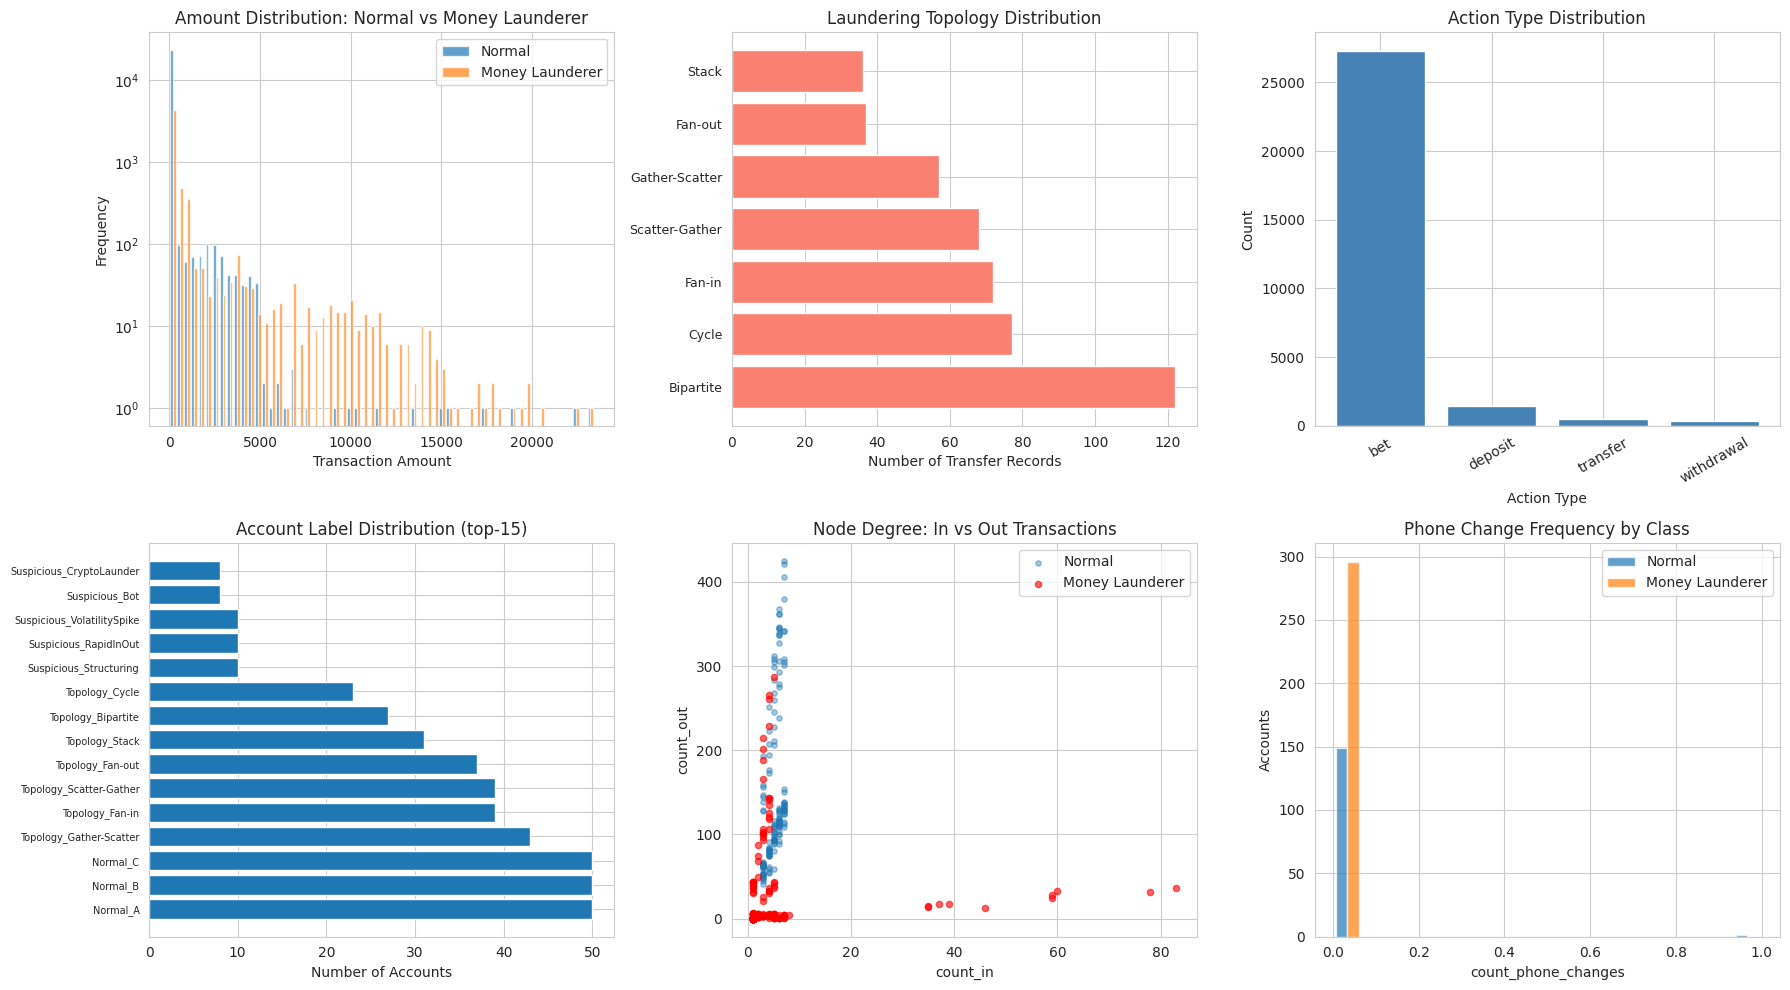

Visualization saved to: ../data/data_generation_summary.png


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Amount distribution: normal vs money-launderer transfer edges
tx_df = df[df['amount'].notna()].copy()
axes[0, 0].hist(
    [tx_df[~tx_df['money_launderer']]['amount'].dropna(),
     tx_df[tx_df['money_launderer']]['amount'].dropna()],
    bins=60, label=['Normal', 'Money Launderer'], alpha=0.7
)
axes[0, 0].set_xlabel('Transaction Amount')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Amount Distribution: Normal vs Money Launderer')
axes[0, 0].legend()
axes[0, 0].set_yscale('log')

# 2. Topology breakdown (transfer edges only)
topo_counts = df[df['topology_type'].notna()]['topology_type'].value_counts()
axes[0, 1].barh(range(len(topo_counts)), topo_counts.values, color='salmon')
axes[0, 1].set_yticks(range(len(topo_counts)))
axes[0, 1].set_yticklabels(topo_counts.index, fontsize=9)
axes[0, 1].set_xlabel('Number of Transfer Records')
axes[0, 1].set_title('Laundering Topology Distribution')

# 3. Action type distribution
action_counts = df['action_type'].value_counts()
axes[0, 2].bar(action_counts.index, action_counts.values, color='steelblue')
axes[0, 2].set_xlabel('Action Type')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Action Type Distribution')
for tick in axes[0, 2].get_xticklabels():
    tick.set_rotation(30)

# 4. Account label distribution
label_counts = node_df['player_label'].value_counts().head(15)
axes[1, 0].barh(range(len(label_counts)), label_counts.values)
axes[1, 0].set_yticks(range(len(label_counts)))
axes[1, 0].set_yticklabels(label_counts.index, fontsize=7)
axes[1, 0].set_xlabel('Number of Accounts')
axes[1, 0].set_title('Account Label Distribution (top-15)')

# 5. Node feature: count_in vs count_out coloured by money_launderer
ml = node_df['money_launderer']
axes[1, 1].scatter(node_df[~ml]['count_in'], node_df[~ml]['count_out'],
                   alpha=0.4, s=15, label='Normal')
axes[1, 1].scatter(node_df[ml]['count_in'], node_df[ml]['count_out'],
                   alpha=0.6, s=20, color='red', label='Money Launderer')
axes[1, 1].set_xlabel('count_in')
axes[1, 1].set_ylabel('count_out')
axes[1, 1].set_title('Node Degree: In vs Out Transactions')
axes[1, 1].legend()

# 6. Phone changes distribution by class (Table II / Table III)
axes[1, 2].hist(
    [node_df[~ml]['count_phone_changes'], node_df[ml]['count_phone_changes']],
    bins=15, label=['Normal', 'Money Launderer'], alpha=0.7
)
axes[1, 2].set_xlabel('count_phone_changes')
axes[1, 2].set_ylabel('Accounts')
axes[1, 2].set_title('Phone Change Frequency by Class')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('../data/data_generation_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved to: ../data/data_generation_summary.png")


In [22]:
def print_class_comparison(node_df, df):
    normal = node_df[~node_df['money_launderer']]
    laund  = node_df[node_df['money_launderer']]

    feat_cols = [
        'sum_spending', 'mean_spending', 'median_spending', 'std_spending',
        'max_spending', 'min_spending', 'count_spending',
        'sum', 'mean', 'median', 'std', 'max', 'min',
        'count_in', 'count_out', 'count_unique_in', 'count_unique_out',
        'count_days_in_bank', 'count_phone_changes',
    ]

    W = 72
    print("=" * W)
    print("CLASS COMPARISON: NORMAL vs MONEY LAUNDERER  (node-level features)")
    print("=" * W)
    print(f"  Normal accounts    : {len(normal):>5,}")
    print(f"  Laundering accounts: {len(laund):>5,}")
    print(f"  Class ratio (ML %) : {len(laund) / len(node_df) * 100:.1f}%")

    print("\n" + "-" * W)
    print(f"  {'Feature':<26}  {'Normal mean':>12}  {'Laund. mean':>12}  {'Ratio (L/N)':>11}")
    print("-" * W)
    for col in feat_cols:
        n_mean = normal[col].mean()
        l_mean = laund[col].mean()
        ratio  = (l_mean / n_mean) if n_mean > 0 else float('nan')
        marker = "  ◄" if abs(ratio - 1) > 0.5 and not pd.isna(ratio) else ""
        print(f"  {col:<26}  {n_mean:>12.2f}  {l_mean:>12.2f}  {ratio:>11.2f}{marker}")

    print("\n" + "=" * W)
    print("AMOUNT DISTRIBUTION COMPARISON  (all transaction records)")
    print("=" * W)
    for label, mask in [("Normal", ~df['money_launderer']), ("Laundering", df['money_launderer'])]:
        s = df[mask]['amount'].dropna()
        p = TEMPORAL_PARAMS['normal' if label == 'Normal' else 'laundering']
        print(f"\n  {label} (n={len(s):,})")
        print(f"    Actual   mean  : {s.mean():>10.1f}   |  Expected (Table III): {p['mean_amount']}")
        print(f"    Actual   std   : {s.std():>10.1f}   |  Expected (Table III): {p['std_amount']}")
        print(f"    Actual   median: {s.median():>10.1f}")
        print(f"    Actual   max   : {s.max():>10.1f}")
        print(f"    Actual   min   : {s.min():>10.1f}")

    print("\n" + "=" * W)
    print("TOPOLOGY ACCOUNT BREAKDOWN")
    print("=" * W)
    topo_labels = node_df[node_df['player_label'].str.startswith('Topology')]
    print(topo_labels['player_label'].value_counts().to_string())

    print("\n" + "=" * W)
    print("PHONE CHANGE COMPARISON  (Table III temporal params)")
    print("=" * W)
    for label, grp, cls in [("Normal", normal, 'normal'), ("Laundering", laund, 'laundering')]:
        p = TEMPORAL_PARAMS[cls]
        print(f"\n  {label}")
        print(f"    Actual   mean changes : {grp['count_phone_changes'].mean():.2f}")
        print(f"    Actual   std  changes : {grp['count_phone_changes'].std():.2f}")
        print(f"    Expected inter-change : every {p['mean_phone_change_freq']} ± {p['std_phone_change_freq']} days")

    print("\n" + "=" * W)
    print("◄ marks features where laundering mean differs >50% from normal mean")
    print("=" * W)


print_class_comparison(node_df, df)


CLASS COMPARISON: NORMAL vs MONEY LAUNDERER  (node-level features)
  Normal accounts    :   150
  Laundering accounts:   296
  Class ratio (ML %) : 66.4%

------------------------------------------------------------------------
  Feature                      Normal mean   Laund. mean  Ratio (L/N)
------------------------------------------------------------------------
  sum_spending                    17660.39      11362.07         0.64
  mean_spending                     117.18       2931.45        25.02  ◄
  median_spending                   114.89       2800.86        24.38  ◄
  std_spending                       65.51        410.60         6.27  ◄
  max_spending                      570.73       4308.85         7.55  ◄
  min_spending                       40.17       2750.91        68.49  ◄
  count_spending                    152.60         17.27         0.11  ◄
  sum                             27564.82      22422.59         0.81
  mean                              174.67       31

Graph cluster summary:
  Fan-out  (group 0): 6 nodes, 5 edges
  Fan-in  (group 0): 10 nodes, 15 edges
  Scatter-Gather  (group 0): 10 nodes, 14 edges
  Cycle  (group 0): 7 nodes, 7 edges
  Stack  (group 0): 8 nodes, 7 edges
  Bipartite  (group 0): 8 nodes, 17 edges


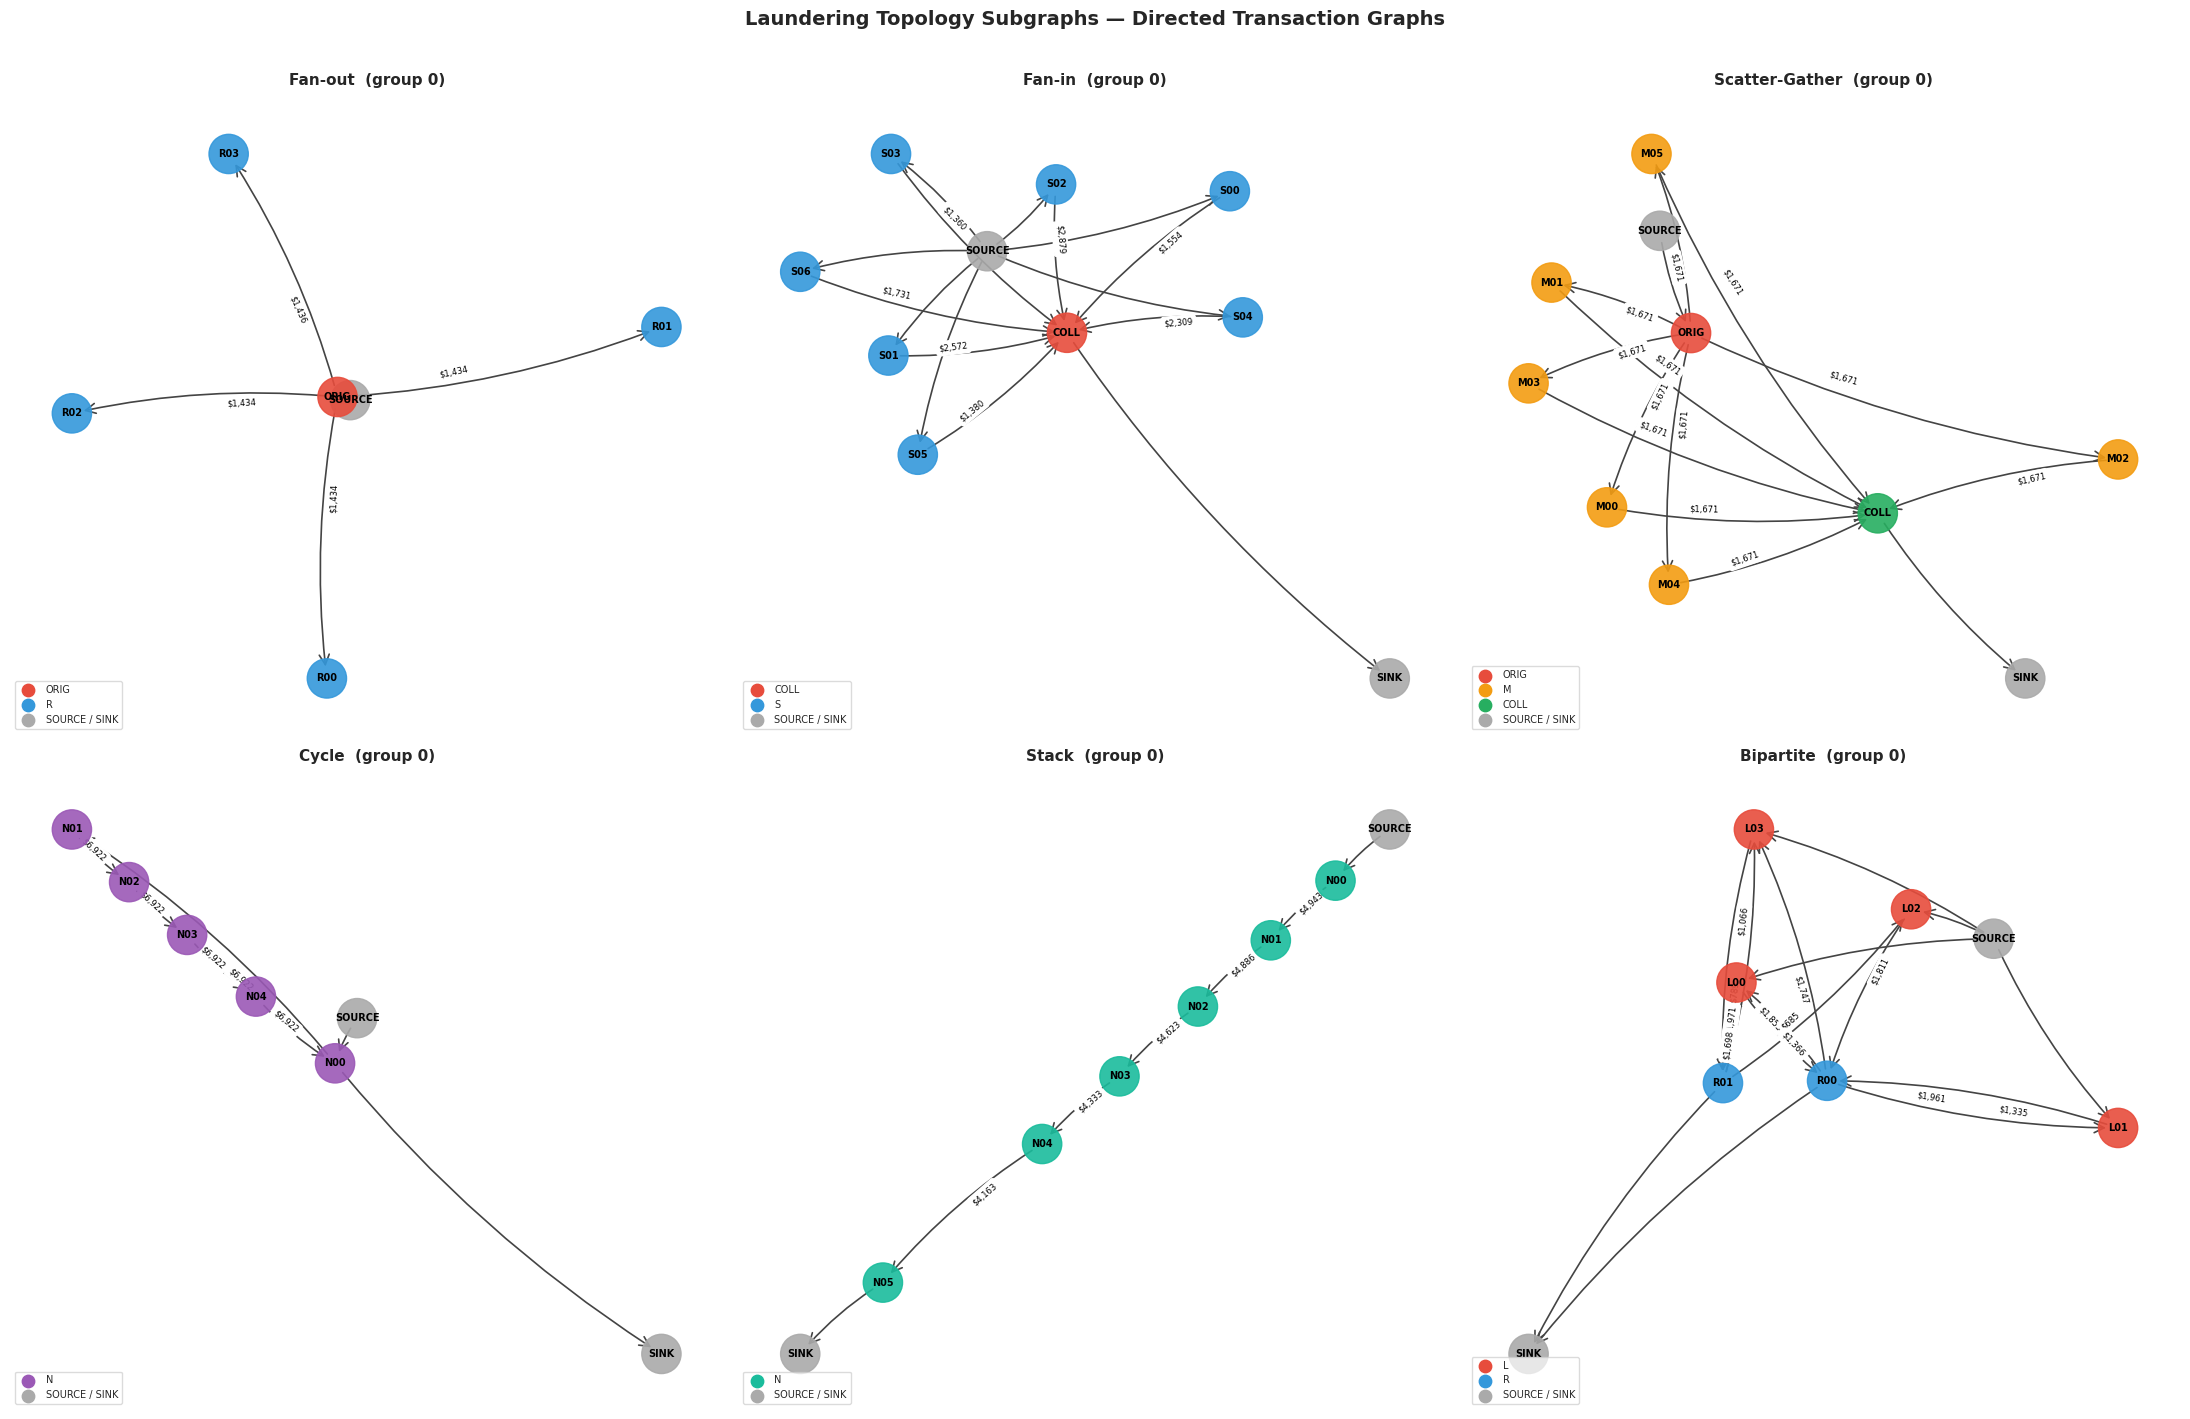


Saved to: ../data/topology_graphs.png


In [23]:
import networkx as nx

def get_cluster_edges(edge_df, account_prefix):
    """Return all edge rows where either endpoint starts with account_prefix."""
    mask = (
        edge_df['from_account'].str.startswith(account_prefix) |
        edge_df['to_account'].str.startswith(account_prefix)
    )
    return edge_df[mask]


def draw_topology_cluster(ax, edge_df, account_prefix, title, node_color_map):
    """
    Build and draw a directed graph for the given topology cluster.
    node_color_map: dict mapping account-prefix fragments → colour.
    """
    cluster_edges = get_cluster_edges(edge_df, account_prefix)

    G = nx.DiGraph()
    for _, row in cluster_edges.iterrows():
        G.add_edge(row['from_account'], row['to_account'],
                   weight=row['amount'], label=f"${row['amount']:,.0f}")

    # Node colours
    def node_colour(n):
        if n in ("SOURCE", "SINK", "PLATFORM"):
            return "#aaaaaa"
        for frag, col in node_color_map.items():
            if frag in n:
                return col
        return "#cccccc"

    colours = [node_colour(n) for n in G.nodes()]

    # Short display labels — only for nodes actually in G
    prefix_strip = account_prefix
    labels = {}
    for n in G.nodes():
        if n in ("SOURCE", "SINK", "PLATFORM"):
            labels[n] = n
        else:
            short = n.replace(prefix_strip, "").lstrip("_")
            labels[n] = short if short else n

    pos = nx.spring_layout(G, seed=42, k=1.8)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colours, node_size=800, alpha=0.9)
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=7, font_weight='bold')
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True,
                           arrowstyle='->', arrowsize=18,
                           edge_color='#444444', width=1.2,
                           connectionstyle='arc3,rad=0.08')

    # Edge amount labels (skip SOURCE/SINK edges to keep it readable)
    edge_labels = {
        (u, v): f"${d['weight']:,.0f}"
        for u, v, d in G.edges(data=True)
        if u not in ("SOURCE", "SINK") and v not in ("SOURCE", "SINK")
    }
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
                                 font_size=6, label_pos=0.35)

    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.axis('off')

    # Legend
    for frag, col in node_color_map.items():
        ax.scatter([], [], c=col, label=frag.strip("_"), s=80)
    ax.scatter([], [], c='#aaaaaa', label='SOURCE / SINK', s=80)
    ax.legend(fontsize=7, loc='lower left', framealpha=0.7)

    print(f"  {title}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    return G


# ── one instance of each topology ────────────────────────────────────────────
CLUSTERS = [
    ("TOPO_FO_0000",  "Fan-out  (group 0)",
        {"_ORIG": "#e74c3c", "_R": "#3498db"}),

    ("TOPO_FI_0000",  "Fan-in  (group 0)",
        {"_COLL": "#e74c3c", "_S": "#3498db"}),

    ("TOPO_SG_0000",  "Scatter-Gather  (group 0)",
        {"_ORIG": "#e74c3c", "_M": "#f39c12", "_COLL": "#27ae60"}),

    ("TOPO_CYC_0000", "Cycle  (group 0)",
        {"_N": "#9b59b6"}),

    ("TOPO_STK_0000", "Stack  (group 0)",
        {"_N": "#1abc9c"}),

    ("TOPO_BI_0000",  "Bipartite  (group 0)",
        {"_L": "#e74c3c", "_R": "#3498db"}),
]

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes = axes.flatten()

print("Graph cluster summary:")
for ax, (prefix, title, cmap) in zip(axes, CLUSTERS):
    draw_topology_cluster(ax, edge_df, prefix, title, cmap)

plt.suptitle("Laundering Topology Subgraphs — Directed Transaction Graphs",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/topology_graphs.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved to: ../data/topology_graphs.png")
